<a href="https://colab.research.google.com/github/Prathama-1/Prosperity-4---Solo42/blob/main/Round3_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from scipy.optimize import brentq

In [2]:
PRICE_FILES = [
    "prices_round_3_day_0.csv",
    "prices_round_3_day_1.csv",
    "prices_round_3_day_2.csv",
]
TRADE_FILES = [
    "trades_round_3_day_0.csv",
    "trades_round_3_day_1.csv",
    "trades_round_3_day_2.csv",
]

VOUCHERS = ['VEV_4000','VEV_4500','VEV_5000','VEV_5100','VEV_5200',
            'VEV_5300','VEV_5400','VEV_5500','VEV_6000','VEV_6500']
STRIKES  = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]

In [3]:
# Historical TTE: day0=8d, day1=7d, day2=6d (from problem statement)
TTE_MAP = {0: 8, 1: 7, 2: 6}

In [4]:
# ── LOAD DATA ──────────────────────────────────────────────────────────────────
prices = pd.concat([pd.read_csv(f, sep=';') for f in PRICE_FILES], ignore_index=True)
trades = pd.concat([pd.read_csv(f, sep=';') for f in TRADE_FILES], ignore_index=True)

print(f"Prices shape: {prices.shape}")
print(f"Trades shape: {trades.shape}")
print(f"\nProducts: {sorted(prices['product'].unique())}")


Prices shape: (360000, 17)
Trades shape: (4048, 7)

Products: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


In [5]:
# ── HELPER FUNCTIONS ───────────────────────────────────────────────────────────
def bs_call(S, K, T, sigma, r=0):
    """Black-Scholes call price."""
    if T <= 0 or sigma <= 0:
        return max(0, S - K)
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def implied_vol(price, S, K, T, r=0):
    """Find implied vol via Brent's method."""
    intrinsic = max(0, S - K)
    if price <= intrinsic + 1e-6:
        return np.nan
    try:
        return brentq(lambda v: bs_call(S, K, T, v, r) - price, 1e-6, 5.0)
    except Exception:
        return np.nan


def bs_delta(S, K, T, sigma, r=0):
    """Black-Scholes delta for a call."""
    if T <= 0 or sigma <= 0:
        return 1.0 if S > K else 0.0
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)


def bs_vega(S, K, T, sigma, r=0):
    """Black-Scholes vega (per unit sigma)."""
    if T <= 0 or sigma <= 0:
        return 0.0
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

In [6]:
# ── 1. MID-PRICE OVERVIEW ──────────────────────────────────────────────────────
print("\n" + "="*60)
print("1. MID-PRICE STATISTICS PER PRODUCT PER DAY")
print("="*60)

for product in sorted(prices['product'].unique()):
    row_parts = []
    for d in [0, 1, 2]:
        sub = prices[(prices['product'] == product) & (prices['day'] == d)]['mid_price']
        row_parts.append(f"d{d}: μ={sub.mean():.2f} σ={sub.std():.2f}")
    print(f"{product:30s}  |  " + "  |  ".join(row_parts))


1. MID-PRICE STATISTICS PER PRODUCT PER DAY
HYDROGEL_PACK                   |  d0: μ=9990.96 σ=25.33  |  d1: μ=9992.06 σ=37.61  |  d2: μ=9989.40 σ=31.62
VELVETFRUIT_EXTRACT             |  d0: μ=5246.51 σ=13.68  |  d1: μ=5248.39 σ=14.61  |  d2: μ=5255.39 σ=16.99
VEV_4000                        |  d0: μ=1246.52 σ=13.70  |  d1: μ=1248.41 σ=14.63  |  d2: μ=1255.40 σ=17.00
VEV_4500                        |  d0: μ=746.52 σ=13.69  |  d1: μ=748.41 σ=14.63  |  d2: μ=755.40 σ=16.99
VEV_5000                        |  d0: μ=253.26 σ=12.49  |  d1: μ=253.26 σ=13.58  |  d2: μ=258.54 σ=16.15
VEV_5100                        |  d0: μ=168.11 σ=10.95  |  d1: μ=164.98 σ=11.94  |  d2: μ=167.33 σ=14.81
VEV_5200                        |  d0: μ=97.47 σ=8.17  |  d1: μ=95.13 σ=8.66  |  d2: μ=94.05 σ=11.50
VEV_5300                        |  d0: μ=48.89 σ=5.18  |  d1: μ=46.91 σ=5.47  |  d2: μ=44.48 σ=7.06
VEV_5400                        |  d0: μ=18.47 σ=2.78  |  d1: μ=15.65 σ=2.68  |  d2: μ=13.73 σ=3.01
VEV_5500 

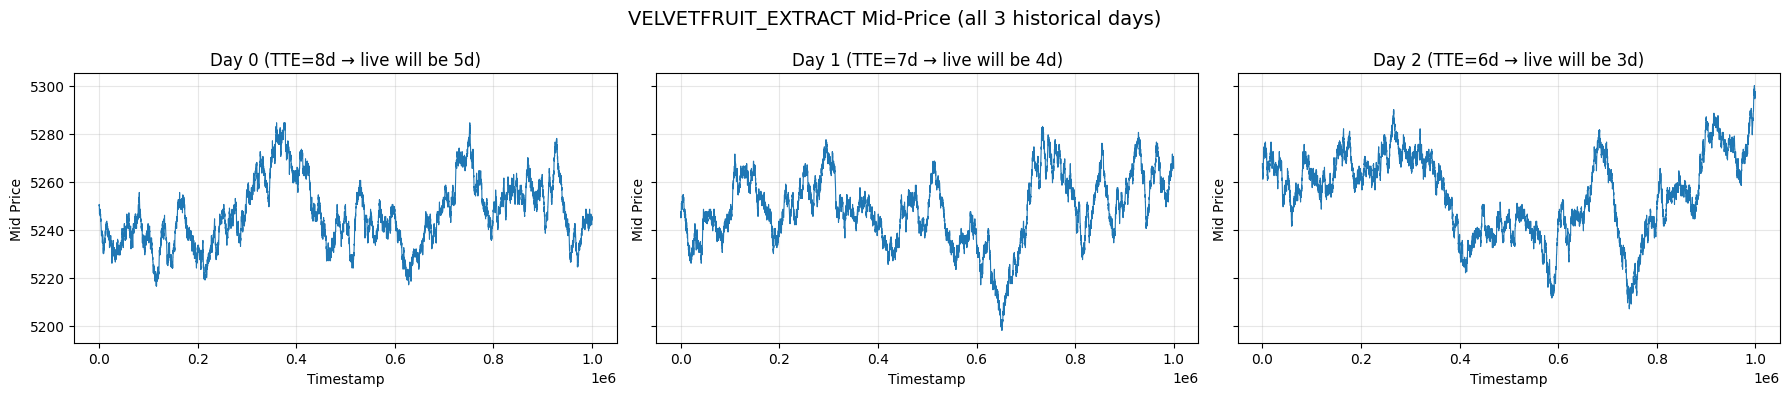

In [7]:
# ── 2. VELVETFRUIT_EXTRACT PRICE PLOT ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
fig.suptitle("VELVETFRUIT_EXTRACT Mid-Price (all 3 historical days)", fontsize=14)

for d in [0, 1, 2]:
    sub = prices[(prices['product'] == 'VELVETFRUIT_EXTRACT') & (prices['day'] == d)]
    axes[d].plot(sub['timestamp'], sub['mid_price'], lw=0.8)
    axes[d].set_title(f"Day {d} (TTE={TTE_MAP[d]}d → live will be {TTE_MAP[d]-3}d)")
    axes[d].set_xlabel("Timestamp")
    axes[d].set_ylabel("Mid Price")
    axes[d].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("velvetfruit_prices.png", dpi=150)
plt.show()


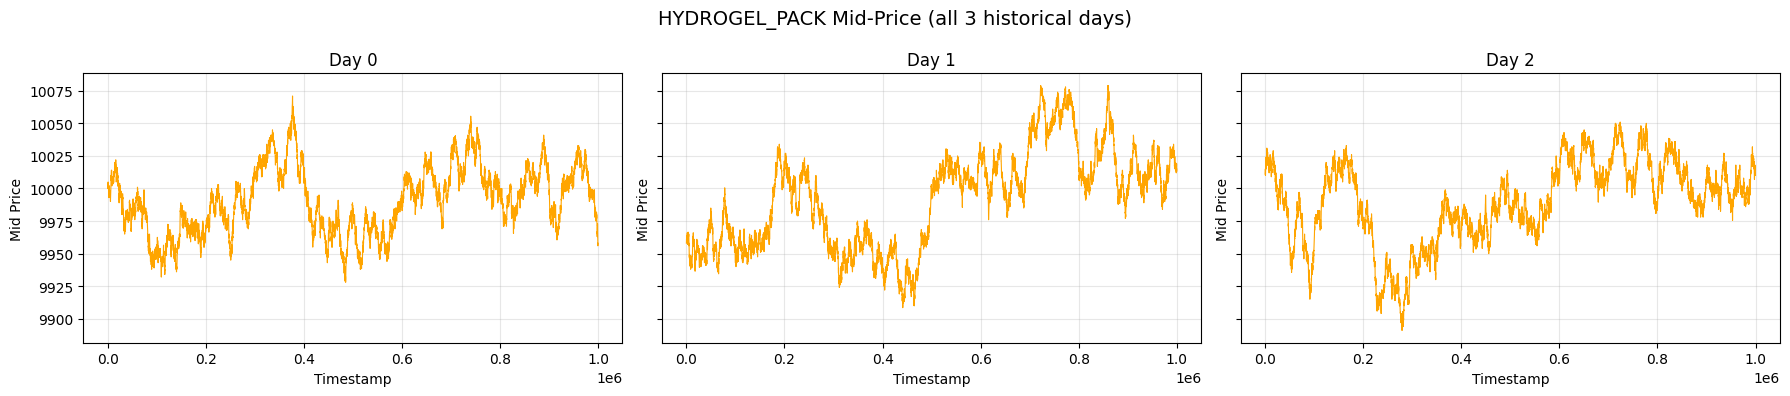

In [8]:
# ── 3. HYDROGEL_PACK PRICE PLOT ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
fig.suptitle("HYDROGEL_PACK Mid-Price (all 3 historical days)", fontsize=14)

for d in [0, 1, 2]:
    sub = prices[(prices['product'] == 'HYDROGEL_PACK') & (prices['day'] == d)]
    axes[d].plot(sub['timestamp'], sub['mid_price'], lw=0.8, color='orange')
    axes[d].set_title(f"Day {d}")
    axes[d].set_xlabel("Timestamp")
    axes[d].set_ylabel("Mid Price")
    axes[d].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("hydrogel_prices.png", dpi=150)
plt.show()